# COMPARISON PANDAS VS DUCKDB

In [ ]:
# ============================================================
# Pandas vs DuckDB CSV Performance Benchmark
# Author: Ghazian Hanafi
# Purpose:
#   Compare memory usage and execution time between Pandas
#   and DuckDB when opening and exploring CSV files.
# Data: IMDB Movie Dataset (380 MB) and OWID CO2 Dataset (13 MB)
# Data sources:
#   - IMDB Movie Dataset:
#   - OWID CO2 Dataset:  
# Datasets:
#   - Medium (~13 MB)
#   - Large (~500 MB)
# ============================================================

import pandas as pd
import duckdb
import os
import time
import psutil

# ============================================================
# CONFIGURATION
# ============================================================
large_dir = "C:\\Users\\ghazi\\OneDrive\\Bismillah Intellectual Property of Ghazian Hirzi Hanafi\\SCI035_RESEARCH\\08_Portofolio\\11_IMDB_dataset\\Data\\"
MEDIUM_CSV = "global_owid-co2-data.csv"   # ~13 MB
LARGE_CSV  = large_dir+"Imdb Movie Dataset.csv"   # replace with your actual file

process = psutil.Process(os.getpid())

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def memory_mb():
    """Return current process memory usage in MB"""
    return process.memory_info().rss / (1024 * 1024)

def benchmark(func, label):
    """Measure execution time and memory usage"""
    mem_before = memory_mb()
    start = time.time()

    result = func()

    elapsed = time.time() - start
    mem_after = memory_mb()

    print("=" * 60)
    print(label)
    print(f"Time elapsed : {elapsed:.2f} seconds")
    print(f"Memory delta : {mem_after - mem_before:.2f} MB")
    print("=" * 60, "\n")

    return result

# ============================================================
# MEDIUM DATASET (~13 MB)
# ============================================================

print("\n###============== MEDIUM DATASET (~13 MB) ==============###\n")

# Pandas: open CSV
df_pandas_medium = benchmark(
    lambda: pd.read_csv(MEDIUM_CSV),
    "Pandas – Open Medium CSV"
)
duckdb.sql()
# DuckDB: open CSV (lazy scan)
df_duckdb_medium = benchmark(
    lambda: duckdb.sql(f"""
        SELECT *
        FROM read_csv_auto('{MEDIUM_CSV}')
        LIMIT 10
    """).df(),
    "DuckDB – Open Medium CSV"
)

# Exploration comparison
# benchmark(
#     lambda: df_pandas_medium.describe(),
#     "Pandas – describe() (Medium)"
# )

# benchmark(
#     lambda: duckdb.sql(f"""
#         SELECT
#             COUNT(*) AS rows,
#             AVG(co2_per_capita) AS avg_co2_pc
#         FROM read_csv_auto('{MEDIUM_CSV}')
#     """).df(),
#     "DuckDB – aggregation (Medium)"
# )

# ============================================================
# LARGE DATASET (~380 MB)
# ============================================================

print("\n###============== LARGE DATASET (~380 MB) ==============###\n")

# Pandas: open CSV (WARNING: high RAM usage)
df_pandas_large = benchmark(
    lambda: pd.read_csv(LARGE_CSV),
    "Pandas – Open Large CSV"
)

# DuckDB: open CSV (safe, lazy)
df_duckdb_large = benchmark(
    lambda: duckdb.sql(f"""
        SELECT *
        FROM read_csv_auto('{LARGE_CSV}')
        LIMIT 10
    """).df(),
    "DuckDB – Open Large CSV"
)

# Aggregation comparison
# benchmark(
#     lambda: duckdb.sql(f"""
#         SELECT
#             COUNT(*) AS rows,
#             AVG(revenue) AS avg_revenue
#         FROM read_csv_auto('{LARGE_CSV}')
#     """).df(),
#     "DuckDB – aggregation (Large)"
# )

# benchmark(
#     lambda: df_pandas_large["revenue"].mean(),
#     "Pandas – aggregation (Large)"
# )

print("\nBenchmark completed.\n")



###============== MEDIUM DATASET (~13 MB) ==============###

Pandas – Open Medium CSV
Time elapsed : 0.19 seconds
Memory delta : 32.81 MB

DuckDB – Open Medium CSV
Time elapsed : 0.46 seconds
Memory delta : 3.50 MB


###============== LARGE DATASET (~380 MB) ==============###

Pandas – Open Large CSV
Time elapsed : 5.90 seconds
Memory delta : 726.02 MB

DuckDB – Open Large CSV
Time elapsed : 0.24 seconds
Memory delta : 4.36 MB


Benchmark completed.



# DATA OBFUSCATION

Paper source: 
1. [Data Obfuscation: A New Class of Security 
Mechanism Providing Anonymity and Desensitization of Useable Data Sets ](https://eecs.wsu.edu/~bakken/tenure/data_obfuscation_submitted_IEEE_Privacy.pdf)
2. [Data Obfuscation: Anonymity
and Desensitization of 
Usable Data Sets](https://blough.ece.gatech.edu/research/papers/ieeesp04.pdf)


<img src=image.png width="450">



,variant,mean_raw,mean_obf,mean_diff,pearson_r,t_p,ks_p
0,ghg_per_capita_random_asymmetric,7.7298,12.7913,+5.0615,0.9439,0.00e+00,0.00e+00
1,ghg_per_capita_random_mean-preserving,7.7298,7.7298,-0.0000,0.0063,1.00e+00,1.00e+00
2,ghg_per_capita_random_mean-shifting,7.7298,12.3472,+4.6174,0.9578,0.00e+00,0.00e+00
3,ghg_per_capita_random_overlap,7.7298,7.7298,+0.0000,0.6360,1.00e+00,1.00e+00
4,ghg_per_capita_random_symmetry,7.7298,7.7494,+0.0196,0.8955,5.16e-01,0.00e+00
5,ghg_per_capita_shift_constant,7.7298,13.4558,+5.7260,1.0000,0.00e+00,0.00e+00
6,ghg_per_capita_shift_random,7.7298,7.7596,+0.0298,0.9435,1.61e-01,0.00e+00


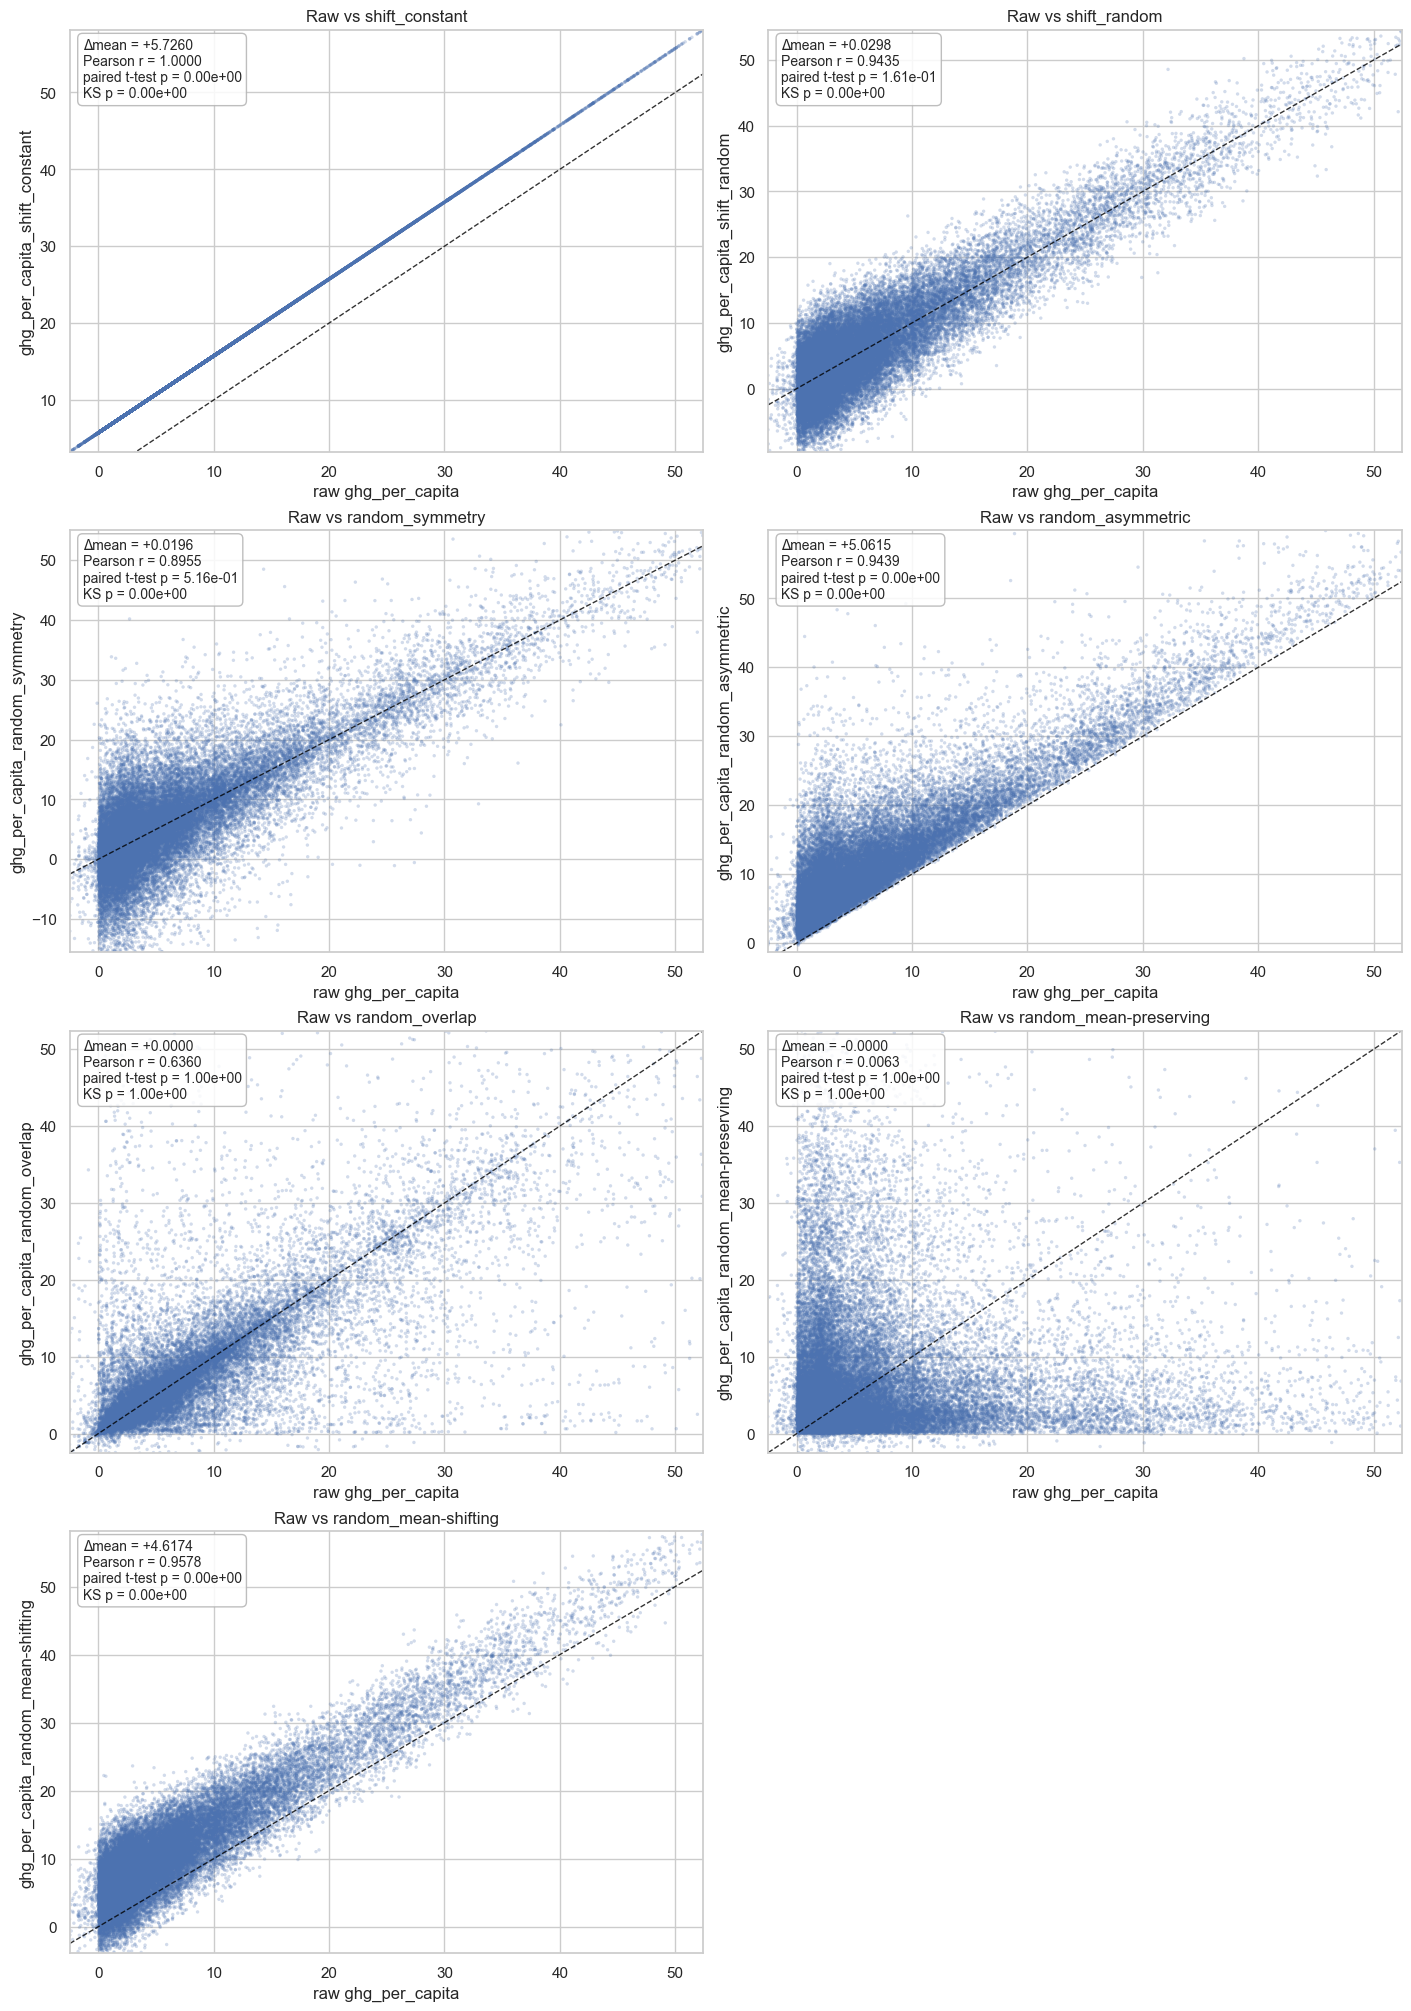

,n,mean_raw,mean_shift_random,corr_raw_shift_random
0,35813,7.729777,7.759555,0.94353


In [ ]:
# --- Ready-to-copy Jupyter cell: DuckDB + OWID CO2 + obfuscation variants + stats + subplots ---
# Assumes you have: global_owid-co2-data.csv in the current working directory.
# Installs (if needed): duckdb, pandas, numpy, scipy, matplotlib, seaborn

import sys, subprocess, importlibe
def _pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

for pkg in ["duckdb", "pandas", "numpy", "scipy", "matplotlib", "seaborn"]:
    try:
        importlib.import_module(pkg)
    except Exception:
        _pip_install([pkg])

import duckdb
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Load data via DuckDB
# -----------------------------
CSV_PATH = "global_owid-co2-data.csv"
TARGET_COL = "ghg_per_capita"

con = duckdb.connect(database=":memory:")
# Read only needed columns if present; fall back to all columns if schema differs
df = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{CSV_PATH}', header=true, sample_size=-1)
""").df()

if TARGET_COL not in df.columns:
    raise ValueError(f"Column '{TARGET_COL}' not found. Available columns: {list(df.columns)[:30]} ...")

# Keep a clean working frame
work = df.copy()
work[TARGET_COL] = pd.to_numeric(work[TARGET_COL], errors="coerce")
work = work.dropna(subset=[TARGET_COL]).reset_index(drop=True)

# Optional: keep only plausible values (avoid extreme parse artifacts)
# Comment out if you want everything.
work = work[(work[TARGET_COL].notna()) & np.isfinite(work[TARGET_COL])].reset_index(drop=True)

raw = work[TARGET_COL].astype(float).to_numpy()

# -----------------------------
# 2) Obfuscation primitives (inspired by "shift" and distribution-shaping ideas)
# -----------------------------
rng = np.random.default_rng(42)

def shift_constant(x, c=None):
    # Constant shift: preserves variance/correlation perfectly, shifts mean by c
    if c is None:
        c = 0.5 * np.nanstd(x)  # scale-aware default
    return x + c

def shift_random(x, scale=None):
    # Random shift per-record: adds noise, reduces correlation, mean ~ preserved if noise mean=0
    if scale is None:
        scale = 0.35 * np.nanstd(x)
    noise = rng.normal(loc=0.0, scale=scale, size=x.shape[0])
    return x + noise

def random_symmetry(x, scale=None):
    # Symmetric noise (zero-mean): mean-preserving in expectation
    if scale is None:
        scale = 0.50 * np.nanstd(x)
    noise = rng.laplace(loc=0.0, scale=scale/np.sqrt(2), size=x.shape[0])  # symmetric, heavier tails
    return x + noise

def random_asymmetric(x, scale=None):
    # Asymmetric noise: pushes distribution one-sided (mean shifts upward)
    if scale is None:
        scale = 0.35 * np.nanstd(x)
    # lognormal is strictly positive; subtract a small constant to keep it "mostly" positive skew
    noise = rng.lognormal(mean=0.0, sigma=0.6, size=x.shape[0])
    noise = (noise - np.mean(noise)) + (0.25 * scale)  # enforce positive mean shift
    noise = noise * (scale / (np.std(noise) + 1e-12))
    return x + noise

def random_overlap(x, window=25):
    # "Overlap" via local rank swapping: preserves global distribution roughly, breaks local order
    # (A simple, explainable proxy for creating overlap between groups/records.)
    n = x.shape[0]
    idx = np.arange(n)
    y = x.copy()
    for i in range(n):
        j = int(np.clip(i + rng.integers(-window, window+1), 0, n-1))
        y[i], y[j] = y[j], y[i]
    return y

def random_mean_preserving(x):
    # Mean-preserving obfuscation: permutation (shuffling) preserves mean and full marginal distribution
    y = x.copy()
    rng.shuffle(y)
    return y

def random_mean_shifting(x, shift=None, scale=None):
    # Mean-shifting noise: explicitly changes mean while also adding randomness
    if scale is None:
        scale = 0.30 * np.nanstd(x)
    if shift is None:
        shift = 0.40 * np.nanstd(x)
    noise = rng.normal(loc=shift, scale=scale, size=x.shape[0])
    return x + noise

# -----------------------------
# 3) Build all variants as new columns
# -----------------------------
variants = {
    "ghg_per_capita_raw": raw,
    "ghg_per_capita_shift_constant": shift_constant(raw),
    "ghg_per_capita_shift_random": shift_random(raw),
    "ghg_per_capita_random_symmetry": random_symmetry(raw),
    "ghg_per_capita_random_asymmetric": random_asymmetric(raw),
    "ghg_per_capita_random_overlap": random_overlap(raw),
    "ghg_per_capita_random_mean-preserving": random_mean_preserving(raw),
    "ghg_per_capita_random_mean-shifting": random_mean_shifting(raw),
}

for k, v in variants.items():
    work[k] = v

# -----------------------------
# 4) Statistical comparison vs raw
#    - mean difference
#    - paired t-test (raw vs obfuscated)
#    - Pearson correlation
#    - KS test (distribution change)
# -----------------------------
def compare_stats(x_raw, x_obf):
    x_raw = np.asarray(x_raw, dtype=float)
    x_obf = np.asarray(x_obf, dtype=float)

    mean_raw = float(np.mean(x_raw))
    mean_obf = float(np.mean(x_obf))
    mean_diff = mean_obf - mean_raw

    # Paired t-test: tests whether mean difference is ~0
    t_stat, t_p = stats.ttest_rel(x_obf, x_raw, nan_policy="omit")

    # Correlation: how much "structure" is preserved
    r, r_p = stats.pearsonr(x_raw, x_obf)

    # KS test: distributional change (marginal)
    ks_stat, ks_p = stats.ks_2samp(x_raw, x_obf)

    return {
        "mean_raw": mean_raw,
        "mean_obf": mean_obf,
        "mean_diff": mean_diff,
        "t_stat": float(t_stat),
        "t_p": float(t_p),
        "pearson_r": float(r),
        "pearson_p": float(r_p),
        "ks_stat": float(ks_stat),
        "ks_p": float(ks_p),
    }

stats_rows = []
for name, arr in variants.items():
    if name == "ghg_per_capita_raw":
        continue
    s = compare_stats(variants["ghg_per_capita_raw"], arr)
    s["variant"] = name
    stats_rows.append(s)

stats_df = pd.DataFrame(stats_rows).sort_values(by="variant").reset_index(drop=True)

# Show a compact stats table
display(stats_df[[
    "variant", "mean_raw", "mean_obf", "mean_diff",
    "pearson_r", "t_p", "ks_p"
]].style.format({
    "mean_raw": "{:.4f}", "mean_obf": "{:.4f}", "mean_diff": "{:+.4f}",
    "pearson_r": "{:.4f}", "t_p": "{:.2e}", "ks_p": "{:.2e}"
}))

# -----------------------------
# 5) Subplots: raw vs each obfuscation
#    Each panel: scatter(raw, obf) + y=x line + stats annotation
# -----------------------------
sns.set_theme(style="whitegrid")

raw_name = "ghg_per_capita_raw"
compare_names = [k for k in variants.keys() if k != raw_name]

n = len(compare_names)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

x = variants[raw_name]
x_min, x_max = np.nanpercentile(x, [1, 99])
pad = 0.05 * (x_max - x_min)
xlim = (x_min - pad, x_max + pad)

for i, name in enumerate(compare_names):
    ax = axes[i]
    y = variants[name]

    # Scatter (subsample if huge)
    N = x.shape[0]
    if N > 200_000:
        idx = rng.choice(N, size=200_000, replace=False)
        xs, ys = x[idx], y[idx]
    else:
        xs, ys = x, y

    ax.scatter(xs, ys, s=6, alpha=0.25, edgecolor="none")
    ax.plot(xlim, xlim, color="black", linewidth=1, linestyle="--", alpha=0.8)

    ax.set_title(f"Raw vs {name.replace('ghg_per_capita_', '')}")
    ax.set_xlabel("raw ghg_per_capita")
    ax.set_ylabel(name)

    ax.set_xlim(xlim)
    y_min, y_max = np.nanpercentile(y, [1, 99])
    ypad = 0.05 * (y_max - y_min)
    ax.set_ylim((y_min - ypad, y_max + ypad))

    s = compare_stats(x, y)
    annotation = (
        f"Δmean = {s['mean_diff']:+.4f}\n"
        f"Pearson r = {s['pearson_r']:.4f}\n"
        f"paired t-test p = {s['t_p']:.2e}\n"
        f"KS p = {s['ks_p']:.2e}"
    )
    ax.text(
        0.02, 0.98, annotation,
        transform=ax.transAxes, va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.show()

# -----------------------------
# 6) Optional: write back to DuckDB for SQL exploration
# -----------------------------
con.register("owid_obfuscated", work)
# Example query:
display(con.execute("""
    SELECT
      COUNT(*) AS n,
      AVG(ghg_per_capita_raw) AS mean_raw,
      AVG(ghg_per_capita_shift_random) AS mean_shift_random,
      CORR(ghg_per_capita_raw, ghg_per_capita_shift_random) AS corr_raw_shift_random
    FROM owid_obfuscated
""").df())

# If you want to export the augmented dataset:
# work.to_csv("global_owid-co2-data_obfuscated.csv", index=False)

# On Progress 

In [ ]:
duckdb.sql("""
SELECT *
FROM read_csv_auto('global_owid-co2-data.csv')
LIMIT 0;
""").show()

In [42]:
import duckdb

con = duckdb.connect("climate.duckdb")

# Load table if not exists
con.sql("""
CREATE OR REPLACE TABLE co2 AS
SELECT *
FROM read_csv_auto('global_owid-co2-data.csv');
""")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create view with obfuscation variants
df_indo = con.sql("""
WITH base AS (
    SELECT
        year,
        ghg_per_capita,
        AVG(ghg_per_capita) OVER () AS mean_val
    FROM read_csv_auto('global_owid-co2-data.csv')
    WHERE country = 'Indonesia'
)

SELECT
    year,

    -- 1. Raw
    ghg_per_capita AS ghg_per_capita_raw,

    -- 2. Constant shift (+1)
    ghg_per_capita + 1 AS ghg_per_capita_shift_constant,

    -- 3. Random shift (uniform noise)
    ghg_per_capita + (RANDOM() - 0.5) AS ghg_per_capita_shift_random,

    -- 4. Random symmetric (mean-centered noise)
    ghg_per_capita + (RANDOM() - 0.5) * 2 AS ghg_per_capita_random_symmetry,

    -- 5. Random asymmetric (only positive noise)
    ghg_per_capita + RANDOM() AS ghg_per_capita_random_asymmetric,

    -- 6. Random overlap (small noise, high overlap)
    ghg_per_capita + (RANDOM() - 0.5) * 0.3 AS ghg_per_capita_random_overlap,

    -- 7. Random mean-preserving
    ghg_per_capita + ((RANDOM() - 0.5) * 2)
        - AVG((RANDOM() - 0.5) * 2) OVER () AS ghg_per_capita_random_mean_preserving,

    -- 8. Random mean-shifting
    ghg_per_capita + ((RANDOM() - 0.5) * 2) + 0.8 AS ghg_per_capita_random_mean_shifting

FROM base
ORDER BY year

""").df()

df_indo.head()


,year,ghg_per_capita_raw,ghg_per_capita_shift_constant,ghg_per_capita_shift_random,ghg_per_capita_random_symmetry,ghg_per_capita_random_asymmetric,ghg_per_capita_random_overlap,ghg_per_capita_random_mean_preserving,ghg_per_capita_random_mean_shifting
0,1850,4.410,5.410,4.098551,4.419621,4.885561,4.372939,4.290387,4.701808
1,1851,6.459,7.459,5.962407,6.729210,7.267380,6.591826,6.207203,8.203118
2,1852,6.788,7.788,7.238250,6.442993,7.453190,6.695453,7.070265,8.232389
3,1853,7.449,8.449,7.377947,8.027681,8.030913,7.448840,7.733354,7.585147
4,1854,8.411,9.411,8.197673,9.260796,9.330461,8.299570,8.679563,8.703320


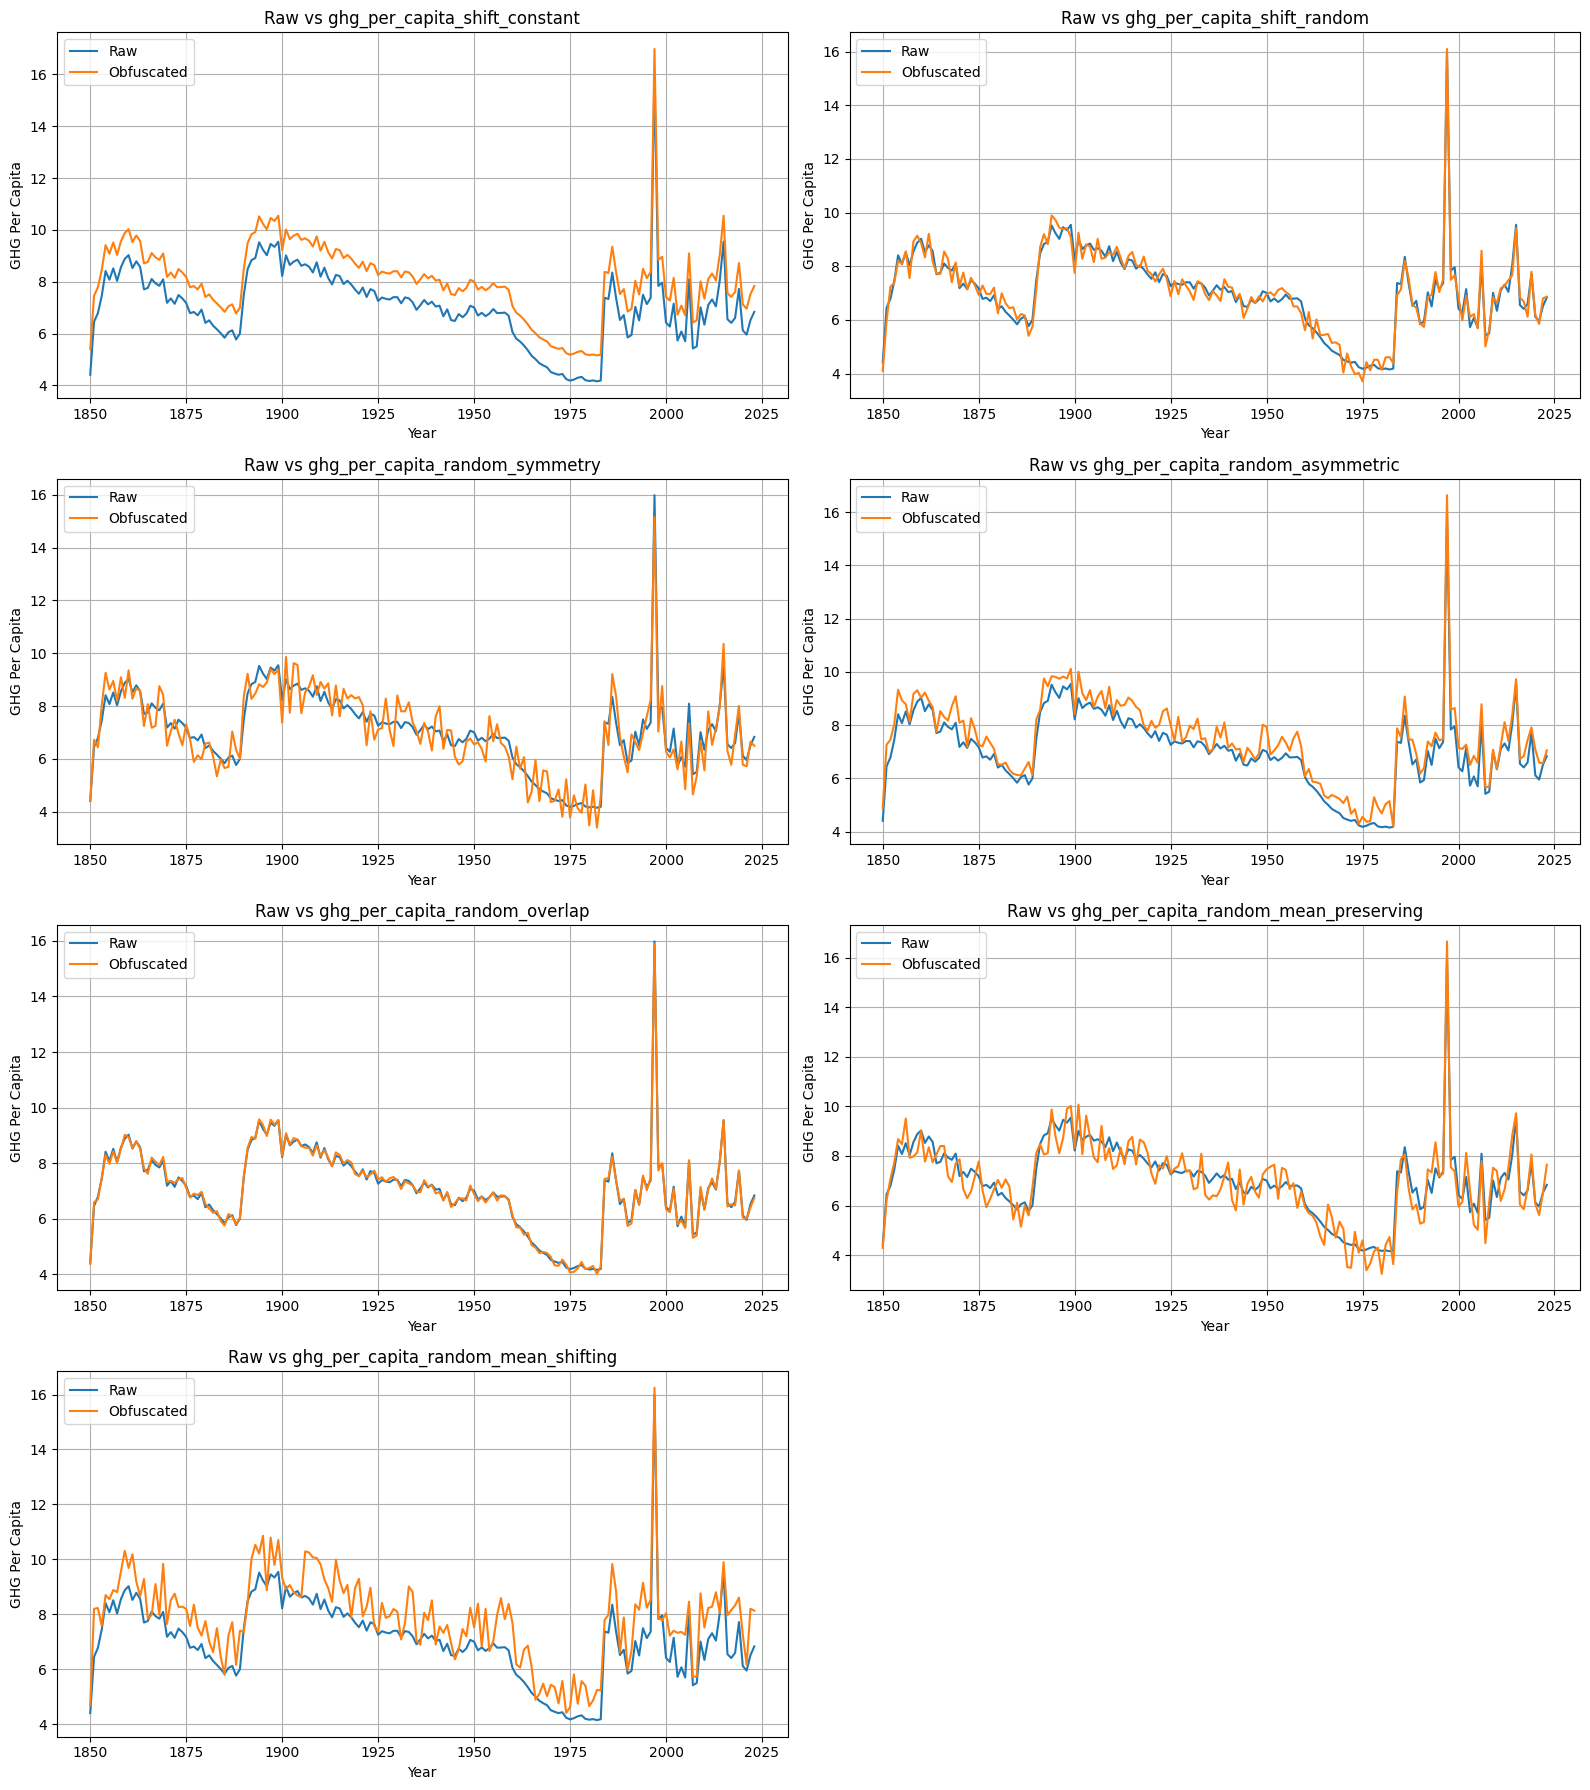

In [44]:
import matplotlib.pyplot as plt

comparisons = [
    'ghg_per_capita_shift_constant',
    'ghg_per_capita_shift_random',
    'ghg_per_capita_random_symmetry',
    'ghg_per_capita_random_asymmetric',
    'ghg_per_capita_random_overlap',
    'ghg_per_capita_random_mean_preserving',
    'ghg_per_capita_random_mean_shifting'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(comparisons):
    axes[i].plot(df_indo['year'], df_indo['ghg_per_capita_raw'], label='Raw')
    axes[i].plot(df_indo['year'], df_indo[col], label='Obfuscated')
    
    axes[i].set_title(f'Raw vs {col}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('GHG Per Capita')
    axes[i].grid(True)
    axes[i].legend()

# Hide last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


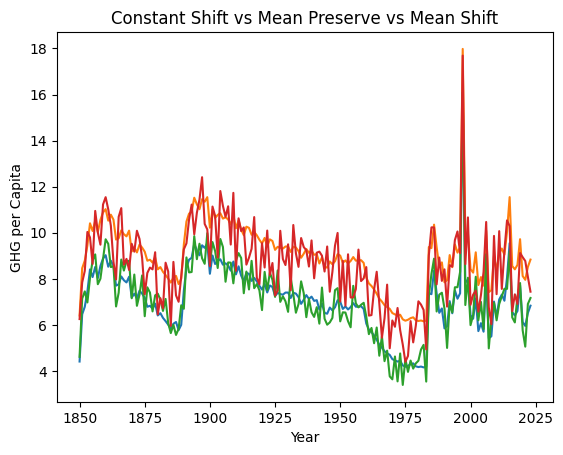

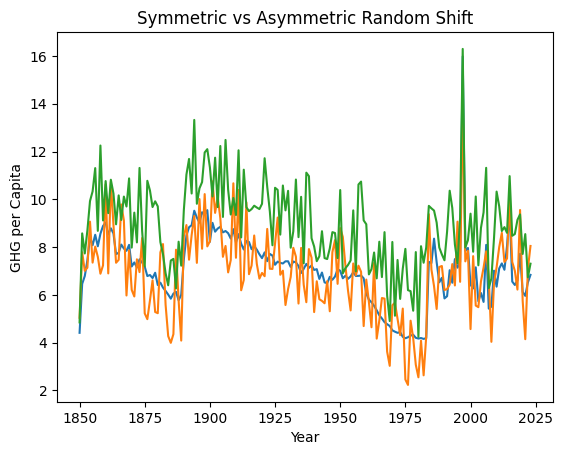

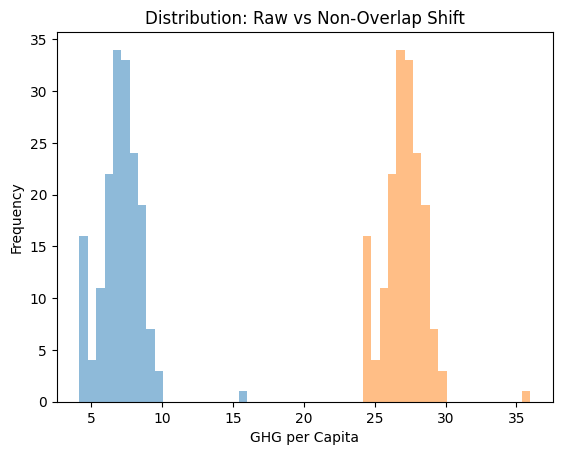

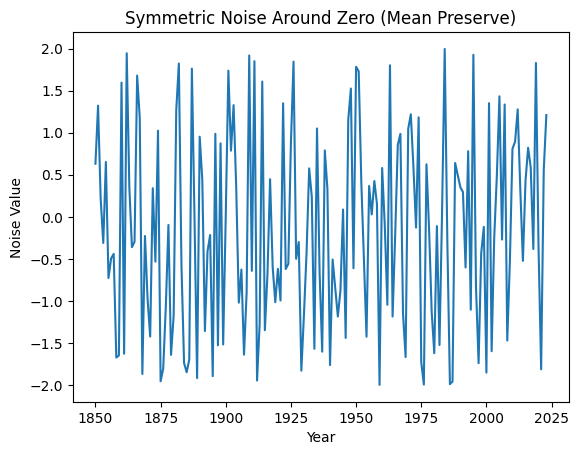

In [34]:
import matplotlib.pyplot as plt

# Sort ascending for proper timeline
df_indo = df_indo.sort_values("year")

# ------------------------------
# 1️⃣ Raw vs Constant vs Mean Preserve vs Mean Shift
# ------------------------------
plt.figure()
plt.plot(df_indo["year"], df_indo["ghg_raw"])
plt.plot(df_indo["year"], df_indo["ghg_shift_constant"])
plt.plot(df_indo["year"], df_indo["ghg_mean_preserve"])
plt.plot(df_indo["year"], df_indo["ghg_mean_shift"])
plt.xlabel("Year")
plt.ylabel("GHG per Capita")
plt.title("Constant Shift vs Mean Preserve vs Mean Shift")
plt.show()


# ------------------------------
# 2️⃣ Symmetric vs Asymmetric Random Shift
# ------------------------------
plt.figure()
plt.plot(df_indo["year"], df_indo["ghg_raw"])
plt.plot(df_indo["year"], df_indo["ghg_symmetric_overlap"])
plt.plot(df_indo["year"], df_indo["ghg_asymmetric"])
plt.xlabel("Year")
plt.ylabel("GHG per Capita")
plt.title("Symmetric vs Asymmetric Random Shift")
plt.show()


# ------------------------------
# 3️⃣ Histogram: Overlap vs Non-Overlap
# ------------------------------
plt.figure()
plt.hist(df_indo["ghg_raw"], bins=20, alpha=0.5)
plt.hist(df_indo["ghg_non_overlap"], bins=20, alpha=0.5)
plt.xlabel("GHG per Capita")
plt.ylabel("Frequency")
plt.title("Distribution: Raw vs Non-Overlap Shift")
plt.show()


# ------------------------------
# 4️⃣ Noise Visualization (Very Important Academically)
# ------------------------------
plt.figure()
plt.plot(df_indo["year"], df_indo["ghg_symmetric_overlap"] - df_indo["ghg_raw"])
plt.xlabel("Year")
plt.ylabel("Noise Value")
plt.title("Symmetric Noise Around Zero (Mean Preserve)")
plt.show()


In [37]:
duckdb.sql("""
    SELECT
        year,
        round(co2_per_capita * (1 + (hash(year) % 10) / 100.0), 2) AS co2_per_capita
    FROM read_csv_auto('global_owid-co2-data.csv')
    WHERE year > 1990
      AND country = 'Indonesia'
""").show()


┌───────┬────────────────┐
│ year  │ co2_per_capita │
│ int64 │     double     │
├───────┼────────────────┤
│  1991 │           1.01 │
│  1992 │           1.05 │
│  1993 │           1.19 │
│  1994 │           1.17 │
│  1995 │           1.18 │
│  1996 │           1.36 │
│  1997 │           1.48 │
│  1998 │           1.22 │
│  1999 │           1.48 │
│  2000 │           1.38 │
│    ·  │             ·  │
│    ·  │             ·  │
│    ·  │             ·  │
│  2014 │           2.05 │
│  2015 │           2.12 │
│  2016 │           2.16 │
│  2017 │           2.27 │
│  2018 │           2.22 │
│  2019 │           2.49 │
│  2020 │           2.21 │
│  2021 │           2.35 │
│  2022 │           2.64 │
│  2023 │           2.76 │
├───────┴────────────────┤
│ 33 rows      2 columns │
│ (20 shown)             │
└────────────────────────┘

